# **Redes Neurais Transformers: Deep Learning com Pytorch**
---



### **1. Configuração do Ambiente**

In [ ]:
!pip install transformers sentencepiece -q

In [ ]:
!pip install datasets -q
!pip install polars

In [ ]:
import re
import shutil
import unicodedata
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass
from collections import Counter
import polars as pl
from tqdm import tqdm
import json
import random
import warnings
from datasets import load_dataset

from transformers import AutoTokenizer
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: Tesla T4


In [ ]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

### **2. Download e Preparação do Dataset**

In [ ]:
import polars as pl
from datasets import load_dataset


class WikipediaPortuguesLoader:

    def __init__(self, version: str = "latest"):
        print("Carregando dataset...")

        dataset = load_dataset(
            "pablo-moreira/wikipedia-pt",
            version,
            split="train"
        )

        self.df = pl.from_pandas(
            dataset.to_pandas()
        ).select("text")

        print(f"Carregado: {len(self.df):,} artigos")

    def carregar_tudo(
        self,
        limite_caracteres: int = 500_000,
        sep_token: str = "[SEP]",
        inserir_sep_final: bool = True
    ) -> str:

        print("Processando textos...")

        df_limpo = (
            self.df
            .filter(pl.col("text").str.len_chars() > 100)
            .with_columns([
                pl.col("text")
                .str.replace_all(r'\[\d+\]', ' ')
                .str.replace_all(r'\{\{[^}]*\}\}', ' ')
                .str.replace_all(r'\[\[([^\]|]+)(?:\|([^\]]+))?\]\]', r'$2')
                .str.replace_all(r'\[\[([^\]]+)\]\]', r'$1')
                .str.replace_all(r'https?://\S+|www\.\S+|\S+@\S+|@\w+', ' ')
                .str.replace_all(r'<[^>]+>', ' ')
                .str.replace_all(r'&\w+;', ' ')
                .str.replace_all(r'==+[^=]*==+', ' ')
                .str.replace_all(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', ' ')
                .str.replace_all(r'[""„‚]', '"')
                .str.replace_all(r"[''‛]", "'")
                .str.replace_all(r'[–—]', '-')
                .str.replace_all(r'[…]', '...')
                .str.replace_all(r'\b\d{5,}\b', ' ')
                .str.replace_all(r'[≈≠≤≥±∞∫∑∏√∂∇∆Ω∀∃∈∉⊂⊃⊆⊇°§]', ' ')
                .str.replace_all(
                    r"[^a-zA-ZáéíóúâêôãõçàÁÉÍÓÚÂÊÔÃÕÇÀüÜ0-9\s\.\,\;\:\!\?\-\(\)\"\'\%]",
                    ' '
                )
                .str.replace_all(r'\.{2,}', '.')
                .str.replace_all(r',{2,}', ',')
                .str.replace_all(r';{2,}', ';')
                .str.replace_all(r':{2,}', ':')
                .str.replace_all(r'\!{2,}', '!')
                .str.replace_all(r'\?{2,}', '?')
                .str.replace_all(r'\s+([,.:;!?])', r'$1')
                .str.replace_all(r'\s+', ' ')
                .str.strip_chars()
            ])
            .filter(
                (pl.col("text").str.len_chars() > 50) &
                (pl.col("text").str.len_chars() < 5000) &
                (
                    pl.col("text").str.count_matches(
                        r'[a-zA-ZáéíóúâêôãõçàÁÉÍÓÚÂÊÔÃÕÇÀüÜ]'
                    ) * 100 / pl.col("text").str.len_chars() > 70
                ) &
                pl.col("text").str.contains(r'[.!?]\s*[A-ZÁÉÍÓÚÂÊÔÃÕÇÀÜ]')
            )
        )

        print(f"Após limpeza: {len(df_limpo):,} artigos")

        textos = df_limpo.get_column("text").to_list()

        corpus_parts = []
        total_len = 0
        textos_adicionados = 0

        prefix = f"{sep_token}\n"
        suffix = "\n"
        prefix_len = len(prefix)
        suffix_len = len(suffix)

        for texto in textos:
            t = (texto or "").strip()
            if not t:
                continue

            bloco = f"{prefix}{t}{suffix}"
            bloco_len = len(bloco)

            if total_len + bloco_len <= limite_caracteres:
                corpus_parts.append(bloco)
                total_len += bloco_len
                textos_adicionados += 1
                continue

            restante = limite_caracteres - total_len
            disponivel_para_texto = restante - prefix_len - suffix_len

            if disponivel_para_texto > 100:
                parc = t[:max(0, disponivel_para_texto)]
                ponto = max(parc.rfind('.'), parc.rfind('!'), parc.rfind('?'))
                if ponto > 0:
                    bloco = f"{prefix}{parc[:ponto+1].rstrip()}{suffix}"
                    corpus_parts.append(bloco)
                    total_len += len(bloco)
                    textos_adicionados += 1
            break

        corpus = "".join(corpus_parts).strip()

        if inserir_sep_final:
            final_tag = f"{sep_token}\n"
            if not corpus.endswith(final_tag):
                if len(corpus) + len(final_tag) <= limite_caracteres:
                    corpus += ("\n" if not corpus.endswith("\n") else "") + final_tag

        print(
            f"Concluído: {len(corpus):,} caracteres "
            f"de {textos_adicionados:,} textos "
            f"(limite: {limite_caracteres:,})"
        )

        return corpus

In [ ]:
loader = WikipediaPortuguesLoader()
textos = loader.carregar_tudo(limite_caracteres = 500_000_000)
print("Exemplo de Texto:\n", textos[1200:2300])

Carregando dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

latest/train-00000-of-00005-f3e8a89f3ba6(…):   0%|          | 0.00/421M [00:00<?, ?B/s]

latest/train-00001-of-00005-bfe0287a799a(…):   0%|          | 0.00/193M [00:00<?, ?B/s]

latest/train-00002-of-00005-7475df3ce56b(…):   0%|          | 0.00/195M [00:00<?, ?B/s]

latest/train-00003-of-00005-4e91be47db0d(…):   0%|          | 0.00/200M [00:00<?, ?B/s]

latest/train-00004-of-00005-5b7359f75323(…):   0%|          | 0.00/274M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1857355 [00:00<?, ? examples/s]

Carregado: 1,857,355 artigos
Processando textos...
Após limpeza: 833,348 artigos
Concluído: 499,999,921 caracteres de 462,345 textos (limite: 500,000,000)
Exemplo de Texto:
 ra do Tejo. Segundo Bernardo Rodrigues, em os "Anais de Arzila", o seu aio era João de Meneses, conde de Cantanhede, e esse acontecimento terá ocasionado nesta personagem um grande traumatismo: Depois da morte de D. Afonso, nomeou como sucessor o Duque de Beja, seu primo, que viria a governar como e que casou depois com Isabel, a viúva do infante Afonso.
[SEP]
A Ideia Perigosa de Darwin A Ideia Perigosa de Darwin (em Portugal) ou A Perigosa Ideia de Darwin (no Brasil), Darwin's Dangerous Idea no original em inglês, é um livro da autoria de Daniel C. Dennett (1995) que explora os efeitos que a teoria da evolução de Charles Darwin terá produzido no pensamento filosófico ocidental. Segundo o autor, a teoria de Darwin sugere que a vida no planeta Terra foi produzida por um processo algorítmico absolutamente cego, enqua

### **3. Tokenizer Pre-Treinado**

In [ ]:
class BertTokenizerWrapper:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(
            "neuralmind/bert-large-portuguese-cased"
        )
        self.tokenizer.clean_up_tokenization_spaces = False


        if self.tokenizer.sep_token_id is not None:
            self.tokenizer.eos_token = self.tokenizer.sep_token
            self.tokenizer.eos_token_id = self.tokenizer.sep_token_id

        if self.tokenizer.cls_token_id is not None:
            self.tokenizer.bos_token = self.tokenizer.cls_token
            self.tokenizer.bos_token_id = self.tokenizer.cls_token_id

        self.vocab_size = len(self.tokenizer)
        self.pad_id = self.tokenizer.pad_token_id
        self.eos_id = self.tokenizer.eos_token_id
        self.bos_id = self.tokenizer.bos_token_id

    def encode(self, text: str, max_length: int = None) -> List[int]:

        return self.tokenizer.encode(
            text,
            truncation=bool(max_length),
            max_length=max_length,
            add_special_tokens=False
        )

    def decode(self, ids: List[int]) -> str:
        return self.tokenizer.decode(ids, skip_special_tokens=True)

    def batch_encode(self, texts: List[str], max_length: int = 512) -> Dict:
        return self.tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
            add_special_tokens=False
        )

In [ ]:
tokenizer = BertTokenizerWrapper()
vocab_size = tokenizer.vocab_size

sample_text = "[SEP] O gato subiu no telhado ontem à noite sozinho porque estava assustado"
encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded)

print(f"Tamanho do Vocabulário: {vocab_size}")
print(f"Texto original: {sample_text}")
print(f"Tokens: (primeiros 10) {encoded}")
print(f"Decodificado: {decoded}")

Tamanho do Vocabulário: 29794
Texto original: [SEP] O gato subiu no telhado ontem à noite sozinho porque estava assustado
Tokens: (primeiros 10) [102, 231, 15997, 10996, 202, 16267, 3185, 2097, 353, 2954, 10580, 2113, 1011, 17154, 487]
Decodificado: O gato subiu no telhado ontem à noite sozinho porque estava assustado


### **4. Positional Encoding**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:


        B, T, C = x.shape

        return x + self.pe[:, :T, :]

### **5. Scaled Dot‑Product Attention SDPA**

In [ ]:
class ScaledDotProductAttention(nn.Module):

    def __init__(self, d_k: int, dropout: float = 0.1):
        super().__init__()
        self.scale = 1.0 / math.sqrt(d_k)
        self.drop = nn.Dropout(dropout)

    def forward(self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor,
                mask: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out  = torch.matmul(attn, V)
        return out, attn

### **6. Implementação de Multi-Head Attention**

In [ ]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model: int, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model deve ser divisível por n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)

        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        self.sdpa = ScaledDotProductAttention(self.d_k, dropout=dropout)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x = x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        return x

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, H, T, D = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, H * D)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None):
        Q = self._split_heads(self.q_proj(x))
        K = self._split_heads(self.k_proj(x))
        V = self._split_heads(self.v_proj(x))

        y, attn = self.sdpa(Q, K, V, mask=mask)

        y = self._merge_heads(y)
        y = self.out_proj(y)
        y = self.proj_drop(y)

        return y, attn

### **7. Feed-Forward Network (FFN)**

In [ ]:
class FeedForward(nn.Module):

    def __init__(self, d_model: int, d_ff: Optional[int] = None, dropout: float = 0.1, activation: str = 'gelu'):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        act = nn.GELU() if activation.lower() == 'gelu' else nn.ReLU(inplace=True)

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            act,
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### **8. Bloco Transformer Completo**

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, d_model: int, n_heads: int = 8, d_ff: Optional[int] = None,
                 dropout: float = 0.1, activation: str = 'gelu'):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout, activation)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None):
        h, attn = self.mha(self.ln1(x), mask=mask)
        x = x + h

        h = self.ffn(self.ln2(x))
        x = x + h

        return x, attn

### **9. Modelo Linguagem**

In [ ]:
from dataclasses import dataclass

@dataclass
class AutoregressiveConfig:
    vocab_size: int
    d_model: int = 512
    n_heads: int = 8
    n_layers: int = 6
    d_ff: int = 2048
    max_len: int = 512
    dropout: float = 0.1
    activation: str = 'gelu'
    weight_tying: bool = True

In [ ]:
class AutoregressiveTransformer(nn.Module):

    def __init__(self, config: AutoregressiveConfig):
        super().__init__()
        self.config = config

        self.token_embedding = nn.Embedding(config.vocab_size, config.d_model)

        self.pos_encoding = PositionalEncoding(config.d_model, config.max_len)

        self.dropout = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(config.d_model, config.n_heads, config.d_ff,
                             config.dropout, config.activation)
            for _ in range(config.n_layers)
        ])

        self.ln_final = nn.LayerNorm(config.d_model)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)

        if config.weight_tying:
            self.token_embedding.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, 0.0, 0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.zeros_(module.bias); nn.init.ones_(module.weight)

    def create_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:

        causal = torch.tril(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool))
        return causal[None, None, :, :]

    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None, pad_id: Optional[int] = None):

        B, T = idx.shape

        max_token_id = torch.max(idx)
        if max_token_id >= self.config.vocab_size:
            raise ValueError(f"Token ID {max_token_id} excede vocab_size {self.config.vocab_size}")

        x = self.token_embedding(idx) * math.sqrt(self.config.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        mask = self.create_causal_mask(T, idx.device)

        if pad_id is not None:
            key_padding = (idx != pad_id).unsqueeze(1).unsqueeze(2)
            mask = mask & key_padding

        attns = []
        for block in self.blocks:
            x, a = block(x, mask)
            attns.append(a)

        x = self.ln_final(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            ignore_idx = pad_id if pad_id is not None else -100
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=ignore_idx
            )

        return logits, loss, attns


    @torch.no_grad()
    def generate(self,
                 idx: torch.Tensor,
                 max_new_tokens: int = 100,
                 temperature: float = 1.0,
                 top_p: Optional[float] = None,
                 top_k: Optional[int] = None,
                 eos_id: Optional[int] = None,
                 repetition_penalty: float = 1.0,
                 return_new_only: bool = False,
                 pad_id: Optional[int] = None):

        self.eval()

        temperature = max(temperature, 1e-8)
        if top_p is not None: top_p = float(min(max(top_p, 0.0), 1.0))
        if top_k is not None: top_k = int(max(1, top_k))

        B, _ = idx.size()
        new_tokens = []

        max_input_id = torch.max(idx)
        if max_input_id >= self.config.vocab_size:
            raise ValueError(f"Input token ID {max_input_id} excede vocab_size {self.config.vocab_size}")

        for _ in range(max_new_tokens):
            ctx = idx[:, -self.config.max_len:]

            logits, _, _ = self(ctx, pad_id=pad_id)
            logits = logits[:, -1, :]

            if repetition_penalty != 1.0:
                for b in range(B):
                    seq = ctx[b] if pad_id is None else ctx[b][ctx[b] != pad_id]
                    uniq = torch.unique(seq)
                    uniq = uniq[uniq < logits.size(-1)]
                    logits[b, uniq] = torch.where(
                        logits[b, uniq] > 0,
                        logits[b, uniq] / repetition_penalty,
                        logits[b, uniq] * repetition_penalty
                    )

            if temperature == 0:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / temperature

                if top_k is not None and top_k < logits.size(-1):
                    v, _ = torch.topk(logits, top_k, dim=-1)
                    logits[logits < v[..., -1, None]] = -float('inf')

                if top_p is not None and 0.0 < top_p < 1.0:
                    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                    sorted_probs = F.softmax(sorted_logits, dim=-1)
                    cumprobs = torch.cumsum(sorted_probs, dim=-1)

                    cutoff = cumprobs > top_p
                    cutoff[..., 1:] = cutoff[..., :-1].clone()
                    cutoff[..., 0] = False
                    sorted_logits[cutoff] = -float('inf')
                    logits = logits.scatter(1, sorted_idx, sorted_logits)

                probs = F.softmax(logits, dim=-1)
                if torch.isnan(probs).any():

                    next_token = torch.argmax(logits, dim=-1, keepdim=True)
                else:
                    next_token = torch.multinomial(probs, num_samples=1)

            if torch.max(next_token) >= self.config.vocab_size:
                break

            idx = torch.cat([idx, next_token], dim=1)
            new_tokens.append(next_token)

            if eos_id is not None and (next_token == eos_id).all():
                break

        if not new_tokens:
            return idx if not return_new_only else torch.empty((B, 0), dtype=idx.dtype, device=idx.device)

        out = torch.cat(new_tokens, dim=1)
        return out if return_new_only else idx

In [ ]:
if 'vocab_size' not in globals():
    print("ERREUR: vocab_size n'est pas défini!")
    print("Veuillez d'abord exécuter la cellule qui crée le tokenizer (cellule 27)")
    print("Elle devrait contenir: tokenizer = BertTokenizerWrapper()")
    raise NameError("vocab_size n'est pas défini. Exécutez d'abord la cellule do tokenizer.")

config = AutoregressiveConfig(
    vocab_size=vocab_size,
    d_model=512,
    n_heads=8,
    n_layers=6,
    d_ff=2048,
    max_len=512,
    dropout=0.1,
    weight_tying=True
)

model = AutoregressiveTransformer(config).to(device)
print(f"\nModelo criado com sucesso!")
print(f"Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")


Modelo criado com sucesso!
Parâmetros totais: 34,157,568


### **10. Preparação dos Dados**

In [ ]:
print("Tokenizando corpus em batches...")

TOKEN_BATCH_SIZE = 1000

all_token_ids = []
for i in range(0, len(textos), TOKEN_BATCH_SIZE):
    batch_texts = textos[i:i + TOKEN_BATCH_SIZE]

    batch_ids = tokenizer.encode(''.join(batch_texts))
    all_token_ids.extend(batch_ids)

    if (i // TOKEN_BATCH_SIZE) % 10 == 0:
        print(f"Processado: {i}/{len(textos)} textos, Tokens: {len(all_token_ids):,}")

print(f"Total de tokens: {len(all_token_ids):,}")

MAX_TOKENS = 5_000_000
if len(all_token_ids) > MAX_TOKENS:
    print(f"Limitando tokens de {len(all_token_ids):,} para {MAX_TOKENS:,}")
    all_token_ids = all_token_ids[:MAX_TOKENS]

data = torch.tensor(all_token_ids, dtype=torch.long)
del all_token_ids

n_train = int(0.75 * len(data))
train_data = data[:n_train]
val_data   = data[n_train:]

print("Dados preparados:")
print(f"   Treino: {len(train_data):,} tokens")
print(f"   Validação: {len(val_data):,} tokens")

A saída de streaming foi truncada nas últimas 5000 linhas.
Processado: 450050000/499999921 textos, Tokens: 106,945,540
Processado: 450060000/499999921 textos, Tokens: 106,948,018
Processado: 450070000/499999921 textos, Tokens: 106,950,469
Processado: 450080000/499999921 textos, Tokens: 106,952,719
Processado: 450090000/499999921 textos, Tokens: 106,954,897
Processado: 450100000/499999921 textos, Tokens: 106,957,030
Processado: 450110000/499999921 textos, Tokens: 106,959,426
Processado: 450120000/499999921 textos, Tokens: 106,961,802
Processado: 450130000/499999921 textos, Tokens: 106,964,261
Processado: 450140000/499999921 textos, Tokens: 106,966,672
Processado: 450150000/499999921 textos, Tokens: 106,969,058
Processado: 450160000/499999921 textos, Tokens: 106,971,511
Processado: 450170000/499999921 textos, Tokens: 106,973,962
Processado: 450180000/499999921 textos, Tokens: 106,976,261
Processado: 450190000/499999921 textos, Tokens: 106,978,813
Processado: 450200000/499999921 textos, T

### **11. Treinamento do Modelo**

In [ ]:
def get_batch(split, batch_size=32, block_size=128):
    data = train_data if split == 'train' else val_data

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)

    for j, i in enumerate(ix):
        x[j] = data[i:i+block_size]
        y[j] = data[i+1:i+block_size+1]

    return x.to(device), y.to(device)


@torch.no_grad()
def estimate_loss(model, eval_iters=100):
    model.eval()
    out = {}

    for split in ['train', 'val']:
        losses = []
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size=batch_size, block_size=block_size)
            logits, loss, _ = model(X, Y)
            losses.append(loss.item())

            del X, Y, logits, loss
            if k % 20 == 0:
                torch.cuda.empty_cache() if torch.cuda.is_available() else None

        out[split] = sum(losses) / len(losses)

    model.train()
    return out

In [ ]:
@torch.no_grad()
def calculate_perplexity(model, split, batch_size=32, block_size=128, n_batches=50):
    model.eval()
    total_loss = 0.0

    for i in range(n_batches):
        x, y = get_batch(split, batch_size, block_size)
        logits, loss, _ = model(x, y)
        total_loss += loss.item()

        del x, y, logits, loss
        if i % 10 == 0:
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    avg_loss = total_loss / n_batches
    ppl = math.exp(avg_loss)

    model.train()
    return ppl

In [ ]:
batch_size    = 32
block_size    = 256
learning_rate = 3e-4
max_iters     = 1_000
eval_interval = 250
eval_iters    = 100
save_interval = 500

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [ ]:
import os
from pathlib import Path

save_dir = Path('/content/drive/MyDrive/modelo_transforms')
save_dir.mkdir(parents=True, exist_ok=True)
print(f"Répertoire de sauvegarde créé: {save_dir}")

Répertoire de sauvegarde créé: /content/drive/MyDrive/modelo_transforms


In [ ]:
print("Iniciando o Treinamento do Modelo (Optimisé pour RAM limitée)")

train_losses, val_losses, val_ppls = [], [], []
best_val_loss = float('inf')

scaler = GradScaler()

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=max_iters // 10,
    T_mult=2,
    eta_min=learning_rate / 100
)

accumulation_steps = 2

for iter in tqdm(range(max_iters), desc="Treinando"):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model, eval_iters)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        val_ppl = calculate_perplexity(model, 'val', batch_size=batch_size, block_size=block_size)
        val_ppls.append(val_ppl)

        print(f"\nIter {iter:5d} | Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | PPL: {val_ppl:.2f}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            if not math.isnan(best_val_loss):
                print(f"   Novo melhor modelo! Val Loss: {best_val_loss:.4f} | Perplexity: {val_ppl:.2f}")

                torch.save({
                    'iter': iter,
                    'model': model.state_dict(),
                    'optim': optimizer.state_dict(),
                    'train_loss': losses['train'],
                    'val_loss': losses['val'],
                    'val_perplexity': val_ppl,
                    'config': config.__dict__,
                    'tokenizer': "neuralmind/bert-large-portuguese-cased"
                }, '/content/drive/MyDrive/modelo_transforms/best_model.pt')

        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if iter % save_interval == 0 and iter > 0:
        print(f"   Checkpoint salvo em iter {iter}")
        torch.save({
            'iter': iter,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': config.__dict__
        }, f'/content/drive/MyDrive/modelo_transforms/checkpoint_{iter}.pt')

    xb, yb = get_batch('train', batch_size, block_size)

    use_autocast = (device.type == 'cuda')
    with autocast(device_type='cuda', enabled=use_autocast):
        logits, loss, _ = model(xb, yb)
        loss = loss / accumulation_steps

    scaler.scale(loss).backward()

    if (iter + 1) % accumulation_steps == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0);

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True);

        scheduler.step()

    del xb, yb, logits, loss
    if iter % 100 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

Iniciando o Treinamento do Modelo (Optimisé pour RAM limitée)


Treinando:   0%|          | 0/1000 [00:00<?, ?it/s]


Iter     0 | Train: 10.4212 | Val: 10.4249 | PPL: 33657.59
   Novo melhor modelo! Val Loss: 10.4249 | Perplexity: 33657.59


Treinando:  25%|██▌       | 250/1000 [01:34<02:24,  5.19it/s]


Iter   250 | Train: 6.5075 | Val: 6.6949 | PPL: 810.49
   Novo melhor modelo! Val Loss: 6.6949 | Perplexity: 810.49


...

Treinando:  75%|███████▌  | 750/1000 [05:04<00:48,  5.15it/s]


Iter   750 | Train: 5.3023 | Val: 5.5912 | PPL: 263.47
   Novo melhor modelo! Val Loss: 5.5912 | Perplexity: 263.47


Treinando: 100%|█████████▉| 998/1000 [06:47<00:00,  5.14it/s]


Iter   999 | Train: 4.8762 | Val: 5.2305 | PPL: 189.28
   Novo melhor modelo! Val Loss: 5.2305 | Perplexity: 189.28


Treinando: 100%|██████████| 1000/1000 [08:12<00:00,  2.03it/s]


In [ ]:
import os
from pathlib import Path

save_dir = Path('./checkpoints')
save_dir.mkdir(exist_ok=True)

additional_iters = 1000
eval_interval = 100
save_interval = 250

start_iter = len(train_losses) * eval_interval if 'train_losses' in globals() else 0

print(f"Reprenant l'entraînement à partir de l'itération {start_iter}")
print(f"Entraînement pour {additional_iters} itérations supplémentaires...")

if 'scaler' not in globals():
    scaler = GradScaler()

accumulation_steps = 2

for iter in tqdm(range(start_iter, start_iter + additional_iters), desc="Entraînement supplémentaire"):

    if iter % eval_interval == 0 or iter == start_iter + additional_iters - 1:
        losses = estimate_loss(model, eval_iters=50)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        val_ppl = calculate_perplexity(model, 'val', batch_size=batch_size, block_size=block_size, n_batches=25)
        val_ppls.append(val_ppl)

        print(f"\nIter {iter:5d} | Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | PPL: {val_ppl:.2f}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            print(f"   ✓ Nouveau meilleur! Val Loss: {best_val_loss:.4f}")
            torch.save({
                'iter': iter,
                'model': model.state_dict(),
                'optim': optimizer.state_dict(),
                'train_loss': losses['train'],
                'val_loss': losses['val'],
                'val_perplexity': val_ppl,
                'config': config.__dict__,
            }, save_dir / 'best_model.pt')

        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if iter % save_interval == 0 and iter > start_iter:
        print(f"   Checkpoint à iter {iter}")
        torch.save({
            'iter': iter,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, save_dir / f'checkpoint_{iter}.pt')

    xb, yb = get_batch('train', batch_size, block_size)

    use_autocast = (device.type == 'cuda')
    with autocast(device_type='cuda', enabled=use_autocast):
        logits, loss, _ = model(xb, yb)
        loss = loss / accumulation_steps

    scaler.scale(loss).backward()

    if (iter + 1) % accumulation_steps == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

    del xb, yb, logits, loss
    if iter % 50 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n✓ Entraînement supplémentaire terminé!")
print(f"Total itérations: {start_iter + additional_iters}")
print(f"Meilleure val loss: {best_val_loss:.4f}")

Reprenant l'entraînement à partir de l'itération 500
Entraînement pour 1000 itérations supplémentaires...


Entraînement supplémentaire:   0%|          | 0/1000 [00:00<?, ?it/s]


Iter   500 | Train: 4.8832 | Val: 5.2202 | PPL: 185.96
   ✓ Nouveau meilleur! Val Loss: 5.2202


Entraînement supplémentaire:  10%|█         | 100/1000 [01:00<02:54,  5.16it/s]


Iter   600 | Train: 4.8185 | Val: 5.1501 | PPL: 164.04
   ✓ Nouveau meilleur! Val Loss: 5.1501


...


Iter  1400 | Train: 4.2461 | Val: 4.7299 | PPL: 110.19
   ✓ Nouveau meilleur! Val Loss: 4.7299


Entraînement supplémentaire: 100%|█████████▉| 998/1000 [11:12<00:00,  5.21it/s]


Iter  1499 | Train: 4.2161 | Val: 4.6139 | PPL: 102.55
   ✓ Nouveau meilleur! Val Loss: 4.6139


Entraînement supplémentaire: 100%|██████████| 1000/1000 [11:52<00:00,  1.40it/s]


✓ Entraînement supplémentaire terminé!
Total itérations: 1500
Meilleure val loss: 4.6139


In [ ]:
import os
from pathlib import Path

save_dir = Path('./checkpoints')
save_dir.mkdir(exist_ok=True)

additional_iters = 1000
eval_interval = 100
save_interval = 250

start_iter = len(train_losses) * eval_interval if 'train_losses' in globals() else 0

print(f"Reprenant l'entraînement à partir de l'itération {start_iter}")
print(f"Entraînement pour {additional_iters} itérations supplémentaires...")

if 'scaler' not in globals():
    scaler = GradScaler()

accumulation_steps = 2

for iter in tqdm(range(start_iter, start_iter + additional_iters), desc="Entraînement supplémentaire"):

    if iter % eval_interval == 0 or iter == start_iter + additional_iters - 1:
        losses = estimate_loss(model, eval_iters=50)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        val_ppl = calculate_perplexity(model, 'val', batch_size=batch_size, block_size=block_size, n_batches=25)
        val_ppls.append(val_ppl)

        print(f"\nIter {iter:5d} | Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | PPL: {val_ppl:.2f}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            print(f"   ✓ Nouveau meilleur! Val Loss: {best_val_loss:.4f}")
            torch.save({
                'iter': iter,
                'model': model.state_dict(),
                'optim': optimizer.state_dict(),
                'train_loss': losses['train'],
                'val_loss': losses['val'],
                'val_perplexity': val_ppl,
                'config': config.__dict__,
            }, save_dir / 'best_model.pt')

        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if iter % save_interval == 0 and iter > start_iter:
        print(f"   Checkpoint à iter {iter}")
        torch.save({
            'iter': iter,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, save_dir / f'checkpoint_{iter}.pt')

    xb, yb = get_batch('train', batch_size, block_size)

    use_autocast = (device.type == 'cuda')
    with autocast(device_type='cuda', enabled=use_autocast):
        logits, loss, _ = model(xb, yb)
        loss = loss / accumulation_steps

    scaler.scale(loss).backward()

    if (iter + 1) % accumulation_steps == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

    del xb, yb, logits, loss
    if iter % 50 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n✓ Entraînement supplémentaire terminé!")
print(f"Total itérations: {start_iter + additional_iters}")
print(f"Meilleure val loss: {best_val_loss:.4f}")

Reprenant l'entraînement à partir de l'itération 1600
Entraînement pour 1000 itérations supplémentaires...


Entraînement supplémentaire:   0%|          | 1/1000 [00:22<6:21:35, 22.92s/it]


Iter  1600 | Train: 4.1600 | Val: 4.6253 | PPL: 104.12


Entraînement supplémentaire:  10%|█         | 100/1000 [00:42<02:55,  5.13it/s]


Iter  1700 | Train: 4.0819 | Val: 4.6092 | PPL: 95.53
   ✓ Nouveau meilleur! Val Loss: 4.6092


...


Iter  2500 | Train: 4.0021 | Val: 4.4633 | PPL: 86.99
   Checkpoint à iter 2500


Entraînement supplémentaire: 100%|█████████▉| 998/1000 [09:50<00:00,  5.18it/s]


Iter  2599 | Train: 3.9872 | Val: 4.4060 | PPL: 83.58


Entraînement supplémentaire: 100%|██████████| 1000/1000 [10:14<00:00,  1.63it/s]


✓ Entraînement supplémentaire terminé!
Total itérations: 2600
Meilleure val loss: 4.4041


In [ ]:
import os
from pathlib import Path

save_dir = Path('./checkpoints')
save_dir.mkdir(exist_ok=True)

additional_iters = 1000
eval_interval = 100
save_interval = 250

start_iter = len(train_losses) * eval_interval if 'train_losses' in globals() else 0

print(f"Reprenant l'entraînement à partir de l'itération {start_iter}")
print(f"Entraînement pour {additional_iters} itérations supplémentaires...")

if 'scaler' not in globals():
    scaler = GradScaler()

accumulation_steps = 2

for iter in tqdm(range(start_iter, start_iter + additional_iters), desc="Entraînement supplémentaire"):

    if iter % eval_interval == 0 or iter == start_iter + additional_iters - 1:
        losses = estimate_loss(model, eval_iters=50)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        val_ppl = calculate_perplexity(model, 'val', batch_size=batch_size, block_size=block_size, n_batches=25)
        val_ppls.append(val_ppl)

        print(f"\nIter {iter:5d} | Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | PPL: {val_ppl:.2f}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            print(f"   ✓ Nouveau meilleur! Val Loss: {best_val_loss:.4f}")
            torch.save({
                'iter': iter,
                'model': model.state_dict(),
                'optim': optimizer.state_dict(),
                'train_loss': losses['train'],
                'val_loss': losses['val'],
                'val_perplexity': val_ppl,
                'config': config.__dict__,
            }, save_dir / 'best_model.pt')

        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if iter % save_interval == 0 and iter > start_iter:
        print(f"   Checkpoint à iter {iter}")
        torch.save({
            'iter': iter,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, save_dir / f'checkpoint_{iter}.pt')

    xb, yb = get_batch('train', batch_size, block_size)

    use_autocast = (device.type == 'cuda')
    with autocast(device_type='cuda', enabled=use_autocast):
        logits, loss, _ = model(xb, yb)
        loss = loss / accumulation_steps

    scaler.scale(loss).backward()

    if (iter + 1) % accumulation_steps == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

    del xb, yb, logits, loss
    if iter % 50 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n✓ Entraînement supplémentaire terminé!")
print(f"Total itérations: {start_iter + additional_iters}")
print(f"Meilleure val loss: {best_val_loss:.4f}")

Reprenant l'entraînement à partir de l'itération 2700
Entraînement pour 1000 itérations supplémentaires...


Entraînement supplémentaire:   0%|          | 0/1000 [00:00<?, ?it/s]


Iter  2700 | Train: 3.9910 | Val: 4.4031 | PPL: 84.68
   ✓ Nouveau meilleur! Val Loss: 4.4031


Entraînement supplémentaire:   5%|▌         | 50/1000 [00:56<03:04,  5.14it/s]

   Checkpoint à iter 2750


...


Iter  3600 | Train: 3.6514 | Val: 4.1998 | PPL: 66.93


Entraînement supplémentaire: 100%|█████████▉| 998/1000 [10:14<00:00,  5.20it/s]


Iter  3699 | Train: 3.5674 | Val: 4.1232 | PPL: 63.47
   ✓ Nouveau meilleur! Val Loss: 4.1232


Entraînement supplémentaire: 100%|██████████| 1000/1000 [11:07<00:00,  1.50it/s]


✓ Entraînement supplémentaire terminé!
Total itérations: 3700
Meilleure val loss: 4.1232


In [ ]:
import os
from pathlib import Path

save_dir = Path('./checkpoints')
save_dir.mkdir(exist_ok=True)

additional_iters = 1000
eval_interval = 100
save_interval = 250

start_iter = len(train_losses) * eval_interval if 'train_losses' in globals() else 0

print(f"Reprenant l'entraînement à partir de l'itération {start_iter}")
print(f"Entraînement pour {additional_iters} itérations supplémentaires...")

if 'scaler' not in globals():
    scaler = GradScaler()

accumulation_steps = 2

for iter in tqdm(range(start_iter, start_iter + additional_iters), desc="Entraînement supplémentaire"):

    if iter % eval_interval == 0 or iter == start_iter + additional_iters - 1:
        losses = estimate_loss(model, eval_iters=50)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        val_ppl = calculate_perplexity(model, 'val', batch_size=batch_size, block_size=block_size, n_batches=25)
        val_ppls.append(val_ppl)

        print(f"\nIter {iter:5d} | Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | PPL: {val_ppl:.2f}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            print(f"   ✓ Nouveau meilleur! Val Loss: {best_val_loss:.4f}")
            torch.save({
                'iter': iter,
                'model': model.state_dict(),
                'optim': optimizer.state_dict(),
                'train_loss': losses['train'],
                'val_loss': losses['val'],
                'val_perplexity': val_ppl,
                'config': config.__dict__,
            }, save_dir / 'best_model.pt')

        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if iter % save_interval == 0 and iter > start_iter:
        print(f"   Checkpoint à iter {iter}")
        torch.save({
            'iter': iter,
            'model': model.state_dict(),
            'optim': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, save_dir / f'checkpoint_{iter}.pt')

    xb, yb = get_batch('train', batch_size, block_size)

    use_autocast = (device.type == 'cuda')
    with autocast(device_type='cuda', enabled=use_autocast):
        logits, loss, _ = model(xb, yb)
        loss = loss / accumulation_steps

    scaler.scale(loss).backward()

    if (iter + 1) % accumulation_steps == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

    del xb, yb, logits, loss
    if iter % 50 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n✓ Entraînement supplémentaire terminé!")
print(f"Total itérations: {start_iter + additional_iters}")
print(f"Meilleure val loss: {best_val_loss:.4f}")

Reprenant l'entraînement à partir de l'itération 3800
Entraînement pour 1000 itérations supplémentaires...


Entraînement supplémentaire:   0%|          | 0/1000 [00:00<?, ?it/s]


Iter  3800 | Train: 3.5494 | Val: 4.1919 | PPL: 66.25


Entraînement supplémentaire:  10%|█         | 100/1000 [00:41<02:53,  5.19it/s]


Iter  3900 | Train: 3.5360 | Val: 4.1718 | PPL: 67.29


...

   Checkpoint à iter 4750


Entraînement supplémentaire: 100%|█████████▉| 998/1000 [09:19<00:00,  5.17it/s]


Iter  4799 | Train: 3.2943 | Val: 4.0756 | PPL: 57.61


Entraînement supplémentaire: 100%|██████████| 1000/1000 [09:43<00:00,  1.71it/s]


✓ Entraînement supplémentaire terminé!
Total itérations: 4800
Meilleure val loss: 4.0216


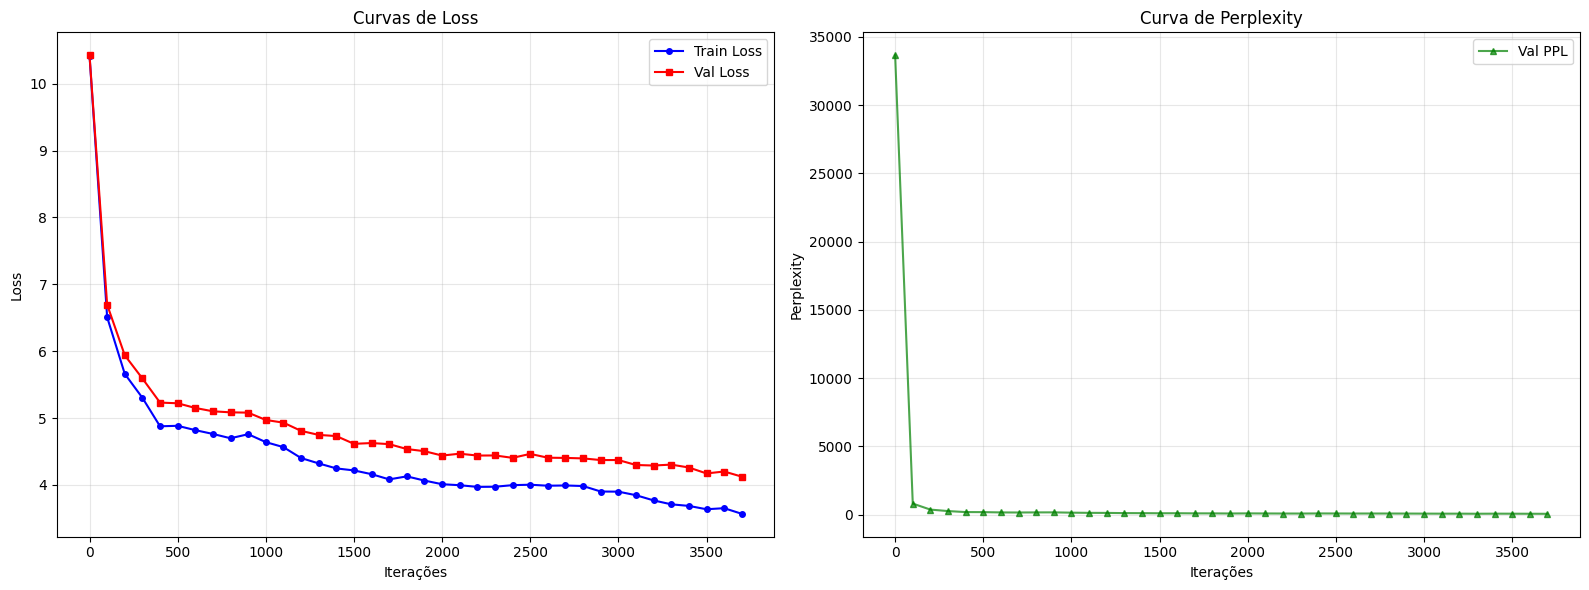

In [ ]:
steps = np.arange(len(train_losses)) * eval_interval

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(steps, train_losses, 'b-', label='Train Loss', marker='o', markersize=4)
axes[0].plot(steps, val_losses, 'r-', label='Val Loss', marker='s', markersize=4)

axes[0].set_xlabel('Iterações')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curvas de Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3);

axes[1].plot(steps, val_ppls, 'g-', label='Val PPL', marker='^', markersize=4, alpha=0.7)

axes[1].set_xlabel('Iterações')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Curva de Perplexity')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3);

plt.tight_layout()
plt.show()

In [ ]:
test_prompts = [
    "antonio guteres e",
    "inteligencia artificial",
    "Ciencia de Dados",
    "Em 2001",
    "O Brasil e um "
]

temperatures = [0.8, 1.0, 1.2]

for prompt in test_prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 60)

    start_ids = tokenizer.encode(prompt, )
    x = torch.tensor([start_ids], dtype=torch.long).to(device)

    for temp in temperatures:
        print(f"\nTemperatura: {temp}")

        with torch.no_grad():
            generated_ids = model.generate(
                x,
                max_new_tokens=20,
                temperature=max(0.1, min(2.0, float(temp))),
                top_k=50,
                top_p=0.9,
                repetition_penalty=1.1,
                eos_id=tokenizer.eos_id,
                pad_id=tokenizer.pad_id
            )
        print(tokenizer.decode(generated_ids[0].tolist()))


Prompt: 'antonio guteres e'
------------------------------------------------------------

Temperatura: 0.8
antonio guteres e savanas, com quatro e nove dias. O espólio de água são exemplos de uma forma

Temperatura: 1.0
antonio guteres e com uma série de três corpos de futebol, o Grupo de NADM foi o festival mais famoso

Temperatura: 1.2
antonio guteres e os " upfras dos ", na frente " araça ". O espólio de

Prompt: 'inteligencia artificial'
------------------------------------------------------------

Temperatura: 0.8
inteligencia artificialmente por uma lei de 1. 000.

Temperatura: 1.0
inteligencia artificial de alimentos ( ou, geralmente na região de que não - é o uso do processo de reprodução.

Temperatura: 1.2
inteligencia artificial ". "

Prompt: 'Ciencia de Dados'
------------------------------------------------------------

Temperatura: 0.8
Ciencia de Dados, em 2020, o PIB " per capita ", com aproximadamente 233, 217 mil

Temperatura: 1.0
Ciencia de Dados do Censo - 2010.

Tem

### **12. Visualização de Attention Patterns**

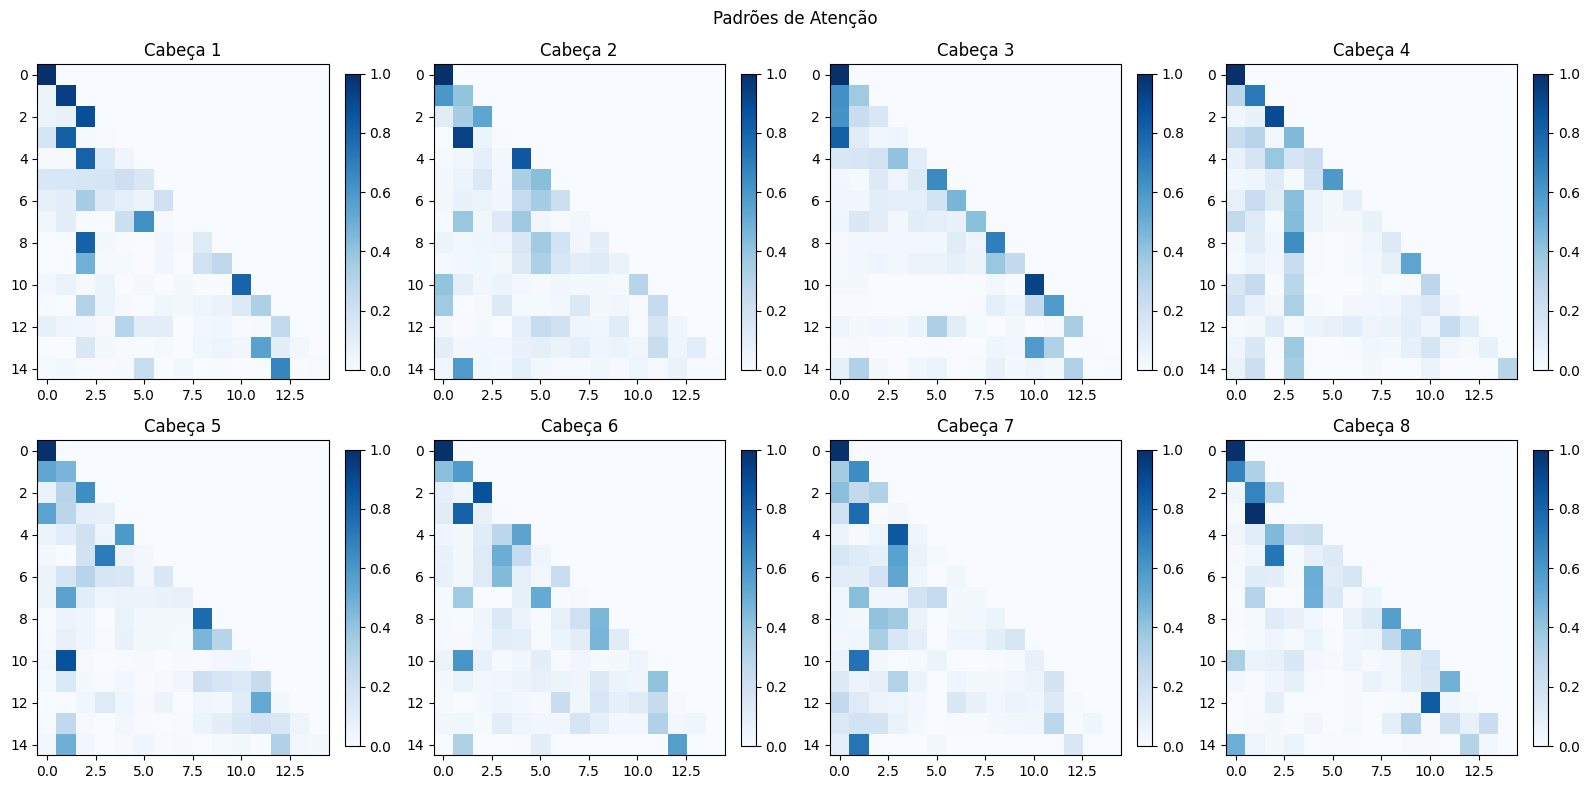

In [ ]:
# Visualizar padrões de atenção da última camada
sample_text = "O gato ."
encoded = tokenizer.encode(sample_text)
sample_ids = tokenizer.encode(sample_text)[:20]
x_sample = torch.tensor([sample_ids], dtype=torch.long).to(device)

with torch.no_grad():
    _, _, attn_weights_all = model(x_sample)

last_layer_attn = attn_weights_all[-1][0].cpu()  # [n_heads, seq_len, seq_len]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head in range(min(8, last_layer_attn.shape[0])):
    attn = last_layer_attn[head].numpy()
    im = axes[head].imshow(attn, cmap='Blues', aspect='auto')
    axes[head].set_title(f'Cabeça {head+1}')
    plt.colorbar(im, ax=axes[head], fraction=0.046)

plt.suptitle('Padrões de Atenção')
plt.tight_layout()
plt.show()

### **13. Avaliação e Métricas**

In [ ]:
train_ppl = calculate_perplexity(model, 'train')
val_ppl = calculate_perplexity(model, 'val')
print(f"Perplexidade Treino: {train_ppl:.2f}")
print(f"Perplexidade Validação: {val_ppl:.2f}")

Perplexidade Treino: 37.57
Perplexidade Validação: 67.04


In [ ]:
final_checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': config.__dict__,
    'tokenizer': "neuralmind/bert-large-portuguese-cased",
    'vocab_size': vocab_size,
    'training_history': {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'final_train_ppl': train_ppl,
        'final_val_ppl': val_ppl,
        'total_iterations': max_iters
    },
    'hyperparameters': {
        'batch_size': batch_size,
        'block_size': block_size,
        'learning_rate': learning_rate,
        'max_iters': max_iters
    }
}
torch.save(final_checkpoint, '/content/drive/MyDrive/modelo_transforms/transformer_final.pt')

torch.save(model.state_dict(), '/content/drive/MyDrive/modelo_transforms/transformer_final_weights.pt')

In [ ]:
with open('/content/drive/MyDrive/modelo_transforms/transformer_final_config.json', 'w') as f:
    json.dump({
        'config': config.__dict__,
        'tokenizer': "neuralmind/bert-large-portuguese-cased",
        'metrics': {
            'train_ppl': train_ppl,
            'val_ppl': val_ppl,
            'best_val_loss': best_val_loss
        }
    }, f, indent=2, default=str)

### **14. Carregamento e Execução do modelo treinado**

In [ ]:
def carregar_modelo(model_path = "/content/transformer_final.pt"):
    checkpoint = torch.load(model_path)

    config_dict = checkpoint['config']
    config = AutoregressiveConfig(**config_dict)

    model = AutoregressiveTransformer(config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    tokenizer = BertTokenizerWrapper()

    return model, tokenizer

In [ ]:
def interface_interativa(model_path = '/content/transformer_final.pt'):
    print("-"*60)
    print("CARREGANDO MODELO TRANSFORMER")

    try:
        model, tokenizer = carregar_modelo(model_path)
    except FileNotFoundError:
        print("Erro: Arquivo 'transformer_final.pt' não encontrado!")
        print("Por favor, treine o modelo primeiro.")
        return

    print("\nDigite 'sair' para encerrar")
    print("-"*60)

    while True:
        print("\n")
        prompt = input("Prompt: ").strip()

        if prompt.lower() == 'sair':
            print("\nEncerrando...")
            break

        if not prompt:
            print("Por favor, digite algum texto!")
            continue

        try:
            max_tokens_input = input("Máximo de tokens (padrão 100): ").strip()
            max_tokens = int(max_tokens_input) if max_tokens_input else 100

            temp_input = input("Temperatura 0.1-2.0 (padrão 0.8): ").strip()
            temperatura = float(temp_input) if temp_input else 0.8
        except ValueError:
            print("Valor inválido, usando padrões")
            max_tokens = 100
            temperatura = 0.8

        print(f"\nGerando com temperatura {temperatura}...")

        try:
            input_ids = tokenizer.encode(prompt)
            x = torch.tensor([input_ids], dtype=torch.long).to(device)

            with torch.no_grad():
                generated_ids = model.generate(
                    x,
                    max_new_tokens=int(max_tokens),
                    temperature=max(0.1, min(2.0, float(temperatura))),
                    top_k=50,
                    top_p=0.9,
                    repetition_penalty=1.1,
                    eos_id=tokenizer.eos_id,
                    pad_id=tokenizer.pad_id
                )

            texto_gerado = tokenizer.decode(generated_ids[0].tolist())
            print("\nTEXTO GERADO:")
            print(texto_gerado)

        except Exception as e:
            print(f"Erro na geração: {e}")